[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kulinskij-tech/AtomicPhys/blob/main/Atomic_py/atomicphys_wavefunc_probs.ipynb)


# Співвідношення невизначеностей Хайзенберга. Задачі на обчислення середніх.

<img src="./figs/atphys_wavefunc_probs1.png" alt="Image" width="600" height="200">

__Розв'язок 6.70__ Згідно з співвідношення Хайзенберга
<!--  -->
$$\langle p^2_x \rangle \langle x^2 \rangle \ge \frac{\hbar^2}{4} \Rightarrow T = \frac{p^2_x}{2\,m} \sim \frac{\hbar^2}{8\,m\,l^2}$$

***
__Розв'язок 6.71__ Згідно з співвідношення Хайзенберга
<!--  -->
$$\Delta \,v_{x}\ge \frac{\hbar}{2\,l} \Rightarrow \frac{\Delta v_x}{v_x} = \frac{\Delta p_x}{p_x} = \frac{\Delta p_x}{\sqrt{2\,m\,T}}$$

<img src="./figs/atphys_wavefunc_probs2.png" alt="Image" width="600" height="200">

__Розв'язок 6.77__ Нормована х.ф. основного стану частинки  ямі є:
<!--  -->
$$
\psi_0(x) = \sqrt{\frac{2}{l}}\,\sin{\frac{\pi\,x}{l}}
$$

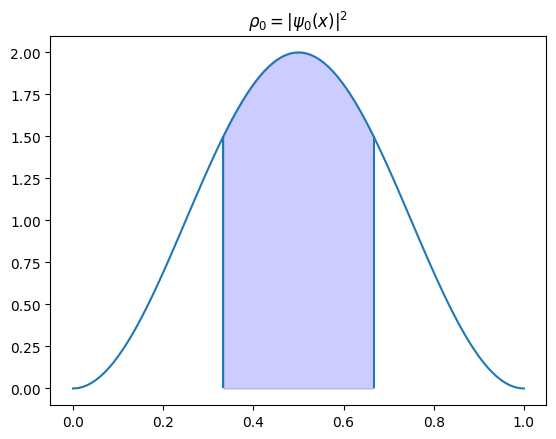

In [1]:
import matplotlib.pyplot as plt
import numpy as np
# 
x=np.linspace(0,1,100)
#
def psix(x):
    return (np.sqrt(2)*np.sin(np.pi*x))**2
# 
x1=1/3
x2=2/3
y=psix(x)
plt.plot(x,y)
l1=plt.vlines(x1,0,psix(1/3))
l2=plt.vlines(x2,0,psix(2/3))
# 
wboolcond=(x > x1) & (x <= x2*1.01)
# 
plt.fill_between(x,y,where = wboolcond,color='b',alpha=0.2)
# plt.legend()
#
plt.title(r'$\rho_{0}=|\psi_{0}(x)|^2$') #not simply \rho but with escape!: \\rho
plt.show()

Питома ймовірність:
$$
p\left(x/l\in [1/3,2/3]\right) = 2\,\int\limits_{1/3}^{2/3}\,\sin^2{\pi\,x}\,dx =
\int\limits_{1/3}^{2/3}\,\left(1- \cos{2\pi\,x}\right)\,dx = \frac{1}{3} - \frac{1}{2\,\pi}\,
-\left(\sin{\frac{4\pi}{3}} - \sin{\frac{4\pi}{3}}\right)\approx 0.61
$$

In [2]:
import sympy 
from sympy import *
# 
c,x=symbols('c x')
l,a= symbols('l a', positive=True)
psi0=sin(pi*x/l)

In [3]:
c=1/sqrt(integrate(psi0**2,[x,0,l]))
c*psi0

sqrt(2)*sin(pi*x/l)/sqrt(l)

In [4]:
p=integrate((c*psi0)**2,[x,l/3,2/3*l])
simplify(p)

(-2*sin(1.33333333333333*pi) + sqrt(3) + 1.33333333333333*pi)/(4*pi)

In [5]:
p.evalf(3)

0.609

<img src="./figs/atphys_wavefunc_probs3.png" alt="Image" width="600" height="200">

__Розв'язок__ Енергія гармонічного осцилятора визначається виразом:
<!--  -->
$$E = \frac{p^2}{2\,m}+\frac{m\,\omega^2\,x^2}{2}$$
тому для середнього:
$$\langle E\rangle = \frac{\langle p^2\rangle}{2\,m}+\frac{m\,\omega^2\,\langle x^2\rangle}{2}$$
<!--  -->
Для основного стану можна вважати, що $\langle p^2\rangle = \langle \Delta p^2\rangle$ тому виходячі з:
$$\langle p^2\rangle\,\langle x^2\rangle \ge \frac{\hbar^2}{4}$$
<!--  -->
$$E\ge \frac{\langle p^2\rangle}{2\,m} + \frac{2}{\hbar^2}\,\frac{m\,\omega^2}{\langle p^2\rangle}$$
Познааючі $y = \langle p^2\rangle$ можна знайти мінімум правої частини що і дає відповідь. 

<a id='zad_rect'></a>
__Задача:__ Стан системи задано фінітним пакетом<a id='wvpack_rect'></a>:
\begin{equation}\label{eq:packrect}
\psi(x) = \left\{\begin{array}{cc}
  C\,, & |x|\le a/2 \\
&\\
  0\,, & |x| > a/2
\end{array} = \theta(x+a/2)\theta(a/2-x) \right.
\end{equation}
де $\theta$ - функція Хевісайда . Визначте амплітуди хвиль де Бройля, які формують цей пакет. Переконайтесь у віконанні  співвідношеня невизначеності. Побудуйте стан у граничному випадку $a \to 0$.<br>

__Розв'язок__ По перше знайдемо константу нормування:
$$
C = \frac{1}{\sqrt{a}}
$$
і дисперсію координати
$$
\sqrt{\langle \Delta x^2 \rangle} = \frac{a}{2\,\sqrt{3}} 
$$

In [6]:
# 
sqrt(1/a*integrate(x**2,[x,-a/2,a/2]))

sqrt(3)*a/6

Амплітуди хвиль де Бройля  як функції хвильового вектора знаходяться елементарним інтегруванням:
$$
c(k) = \frac{1}{\sqrt{2\pi\,a}}\,\int\limits_{-a/2}^{a/2}\,e^{-i\,k\,x} = 
\sqrt{\frac{2}{\pi\,a}}\,\frac{\sin{\frac{k\,a}{2}}}{k}
$$
або в імпульсному представленні:
$$
\tilde{c}(p) = \frac{1}{\sqrt{\hbar}}\,c\left(\frac{p}{\hbar}\right) = 
\sqrt{\frac{2\,\hbar}{\pi\,a}}\,
\frac{\sin\left(\frac{p\,a}{2\hbar}\right)}{p}
$$
<!--  -->
Зауважимо, що середнє значення імпульсу та його диспресія тут невизначені оскільки відповідні інтеграли розбіжні.

In [7]:
x, k = symbols('x k',real=True)
a=symbols('a',positive=True)
#simplify(1/a*integrate(x**2,[x,-a/2,a/2]))#x-disp
simplify(1/sqrt(2*pi*a)*integrate(exp(-I*k*x),[x,-a/2,a/2]))

Piecewise((sqrt(2)*sin(a*k/2)/(sqrt(pi)*sqrt(a)*k), (k > 0) | (k < 0)), (sqrt(2)*sqrt(a)/(2*sqrt(pi)), True))

Проілюструємо співвідношення невизначеностей на цьому прикладі.

In [8]:
# 
from ipywidgets import interactive
import ipywidgets as widgets

In [9]:
# from IPython.display import display
# w = widgets.IntSlider()
# display(w)
#
def f(w):
    plt.figure(figsize=(9, 3))
    plt.subplot(121)
#     plt.figure()
    x = np.linspace(-3, 3, num=100)
    y1=np.heaviside(w/2-x,1)*np.heaviside(x+w/2,1)/np.sqrt(w)
    plt.plot(x, y1)
    plt.fill_between(x,y1,y2=0,color='xkcd:sky blue')
    plt.title("x-rectangular packet")
    # 
    plt.subplot(122)
    k = np.linspace(-25,25, num=100)
    k1=np.sqrt(2/(np.pi*w))*np.sin(k*w/2)/k
    plt.plot(k, k1)
    plt.fill_between(k, k1,y2=0,color='xkcd:sky blue')
    plt.title("its k-fourier transform")
    plt.show()
#
interactive(f, w=(0.1, 4, 0.1))

interactive(children=(FloatSlider(value=2.0, description='w', max=4.0, min=0.1), Output()), _dom_classes=('wid…

Як ми бачимо зменшення ширини пакету у x-просторі збільшує інтервал розподілу у просторі імпульсів та навпаки. 

***
__Приклад: Гаусівський хвильовий пакет__ <br>
$$
\psi (x) = C\exp \left( - \frac{x^{2}}{2\,a^{2}}\right)
$$

__Розв'язок:__ Побудуємо графік функції густини ймовірності $\rho = |\psi(x)|^2$ за різних $a$ (схематично)
 
***

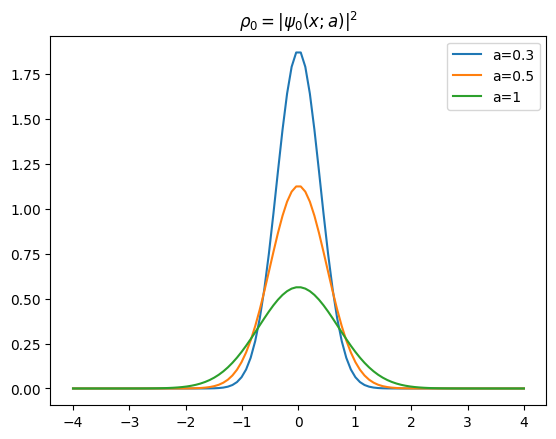

In [10]:
x=np.linspace(-4,4,100)
#
def y(x,a):
    return 1/(np.sqrt(np.pi)*a)*np.exp(-x*x/a)
#
a=[0.3,0.5,1]
#
for av in a: 
    plt.plot(x,y(x,av),label='a='+str(av))
    plt.legend()
#
plt.title('$\\rho_{0}=|\psi_{0}(x;a)|^2$') #not simply \rho but with escape!: \\rho
plt.show()

Нагадаємо інтеграл Пуассона:
<!--  -->
$$\int\limits_{-\infty}^{+\infty} e^{-\frac{x^2}{a^2}}\,dx  = \sqrt{\pi}\,a\,,\,\,\,\,a>0$$

In [11]:
x,k=symbols('x k')
a=Symbol('a',positive=True) # implying condition a>0
integrate(exp(-x**2/(a**2)),[x,-oo,oo]) # poisson integral

sqrt(pi)*a

In [12]:
cnrm=sqrt(1/simplify(integrate(exp(-x**2/(a**2)),[x,-oo,oo]))) # norm integral
cnrm

1/(pi**(1/4)*sqrt(a))

In [13]:
psi = cnrm*exp(-x**2/(2*a**2))
psi

exp(-x**2/(2*a**2))/(pi**(1/4)*sqrt(a))

Первевіримо правильність знаходження сталої нормування:
<!--  -->
$$
\int\limits_{-\infty}^{+\infty} \vert \psi(x)\vert^2\, dx = 1
$$

In [14]:
integrate(psi**2,[x,-oo,oo])

1

Визначимо дисперсію координати:

In [15]:
dispx=sqrt(simplify(integrate(x**2*psi**2,[x,-oo,oo])))
dispx

sqrt(2)*a/2

Фур'є-амплітуди:

In [16]:
ck=integrate(psi*cos(k*x),[x,-oo,oo])/sqrt(2*pi)
ck

sqrt(a)*exp(-a**2*k**2/2)/pi**(1/4)

In [17]:
integrate(ck**2,[k,-oo,oo])

1

In [18]:
dispk=sqrt(integrate(ck**2*k**2,[k,-oo,oo]))
dispk

sqrt(2)/(2*a)

Співвідношення невизначенностей в данному випадку набуває своєї нижньої границі:
$$\Delta x\,\Delta p_{x}  = \frac{\hbar}{2}$$

In [19]:
dispk*dispx

1/2